In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
directory = '/content/drive/MyDrive/DL_Dataset/Data_With_Symbol'

In [ ]:
## Combining every dataset ##

# file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.csv')]
# dataframes = [pd.read_csv(file) for file in file_paths]
# combined_df = pd.concat(dataframes, ignore_index=True)
# print(combined_df)

# combined_df = pd.concat(dataframes, ignore_index=True)
# combined_df.to_csv('combined_data.csv', index=False)

# df = pd.read_csv('combined_data.csv')
# df.head()

In [ ]:
# all_df = []
# file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.csv')]

# for file in file_paths:
#   new_df = pd.read_csv(file)
#   all_df.append(new_df)

# df = pd.concat(all_df , ignore_index=True)

# df['Daily_Return'] = df.groupby('Symbol')['Close Price'].pct_change()

# def cal_annual_return(daily_return):
#   mean_daily_return = np.mean(daily_return)
#   annual_return = (1 + mean_daily_return) ** 252 - 1
#   return annual_return

# annual_return_df = df.groupby('Symbol')['Daily_Return'].apply(cal_annual_return)
# print(annual_return_df)

In [ ]:
# all_df = []
# file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.csv')]

# for file in file_paths:
#   new_df = pd.read_csv(file)
#   all_df.append(new_df)

# df = pd.concat(all_df , ignore_index=True)

# df['Date'] = pd.to_datetime(df['Date'])

# df['Daily_Return'] = df.groupby('Symbol')['Close Price'].pct_change()

# def cal_annual_return(daily_returns):
#     daily_returns = daily_returns.dropna()
#     daily_returns.index = pd.to_datetime(daily_returns.index)
#     cumulative_return = (1 + daily_returns).prod() - 1
#     num_years = (daily_returns.index[-1] - daily_returns.index[0]).days / 365.25
#     annualized_return = (1 + cumulative_return) ** (1 / num_years) - 1
#     return annualized_return

# annual_return_df = df.groupby('Symbol')['Daily_Return'].apply(lambda x : cal_annual_return(x))
# print(annual_return_df)

In [ ]:
all_df = []
file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.csv')]

for file in file_paths:
    new_df = pd.read_csv(file, parse_dates=['Date'], dayfirst=True)  # Explicitly parsing the date column
    all_df.append(new_df)

df = pd.concat(all_df, ignore_index=True)
df = df.rename(columns={'Open Price' : 'Open_Price'})
df = df.rename(columns={'High Price' : 'High_Price'})
df = df.rename(columns={'Low Price' : 'Low_Price'})
df = df.rename(columns={'Close Price' : 'Close_Price'})
df = df.rename(columns={'Total Turnover (Rs.)' : 'Turnover'})

df['Daily_Return'] = df.groupby('Symbol')['Close_Price'].pct_change()

# def cal_annual_return(group):
#     daily_returns = group['Daily_Return'].dropna()
#     if daily_returns.empty:       #to check if the first column is zero or not
#         return np.nan

#     cumulative_return = np.prod(1 + daily_returns) - 1
#     num_days = (group['Date'].iloc[-1] - group['Date'].iloc[0]).days

#     if num_days == 0:
#         return np.nan

#     num_years = num_days / 365.25
#     annualized_return = (1 + cumulative_return) ** (1 / num_years) - 1
#     return annualized_return

# annual_return_df = df.groupby('Symbol').apply(cal_annual_return)
# annual_return_df = annual_return_df.reset_index()
# annual_return_df.columns = ['Symbol' , 'Annualized_Return']
# print(annual_return_df)

# df = df.merge(annual_return_df , on='Symbol' , how='left')
# df.head()

<ipython-input-7-30723d81c4d0>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df = pd.read_csv(file, parse_dates=['Date'], dayfirst=True)  # Explicitly parsing the date column
<ipython-input-7-30723d81c4d0>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df = pd.read_csv(file, parse_dates=['Date'], dayfirst=True)  # Explicitly parsing the date column
<ipython-input-7-30723d81c4d0>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df = pd.read_csv(file, parse_dates=['Date'], dayfirst=True)  # Explicitly parsing the date column
<ipython-input-7-30723d81c4d0>:5: 

In [ ]:
df['Turnover'] = df['Turnover'].astype(float)
df['Turnover'] = df['Turnover'] / 1e7       #conversion to Million
df.head()

,Date,Symbol,Open_Price,High_Price,Low_Price,Close_Price,WAP,No.of Shares,No. of Trades,Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open,Daily_Return
0,2024-07-22,AXISBANK,1288.85,1290.95,1278.50,1283.80,1284.528976,438226,13633,56.291399,NaN,NaN,12.45,-5.05,NaN
1,2024-07-19,AXISBANK,1305.20,1305.90,1288.00,1292.10,1294.878436,395930,11416,51.268122,54474.0,13.76,17.90,-13.10,0.006465
2,2024-07-18,AXISBANK,1300.00,1318.00,1294.80,1309.10,1308.187829,225178,9439,29.457512,92225.0,40.96,23.20,9.10,0.013157
3,2024-07-16,AXISBANK,1307.65,1315.00,1300.05,1303.95,1304.348445,80842,3482,10.544614,38460.0,47.57,14.95,-3.70,-0.003934
4,2024-07-15,AXISBANK,1318.95,1324.55,1305.60,1307.65,1312.782805,1037551,33047,136.207911,159884.0,15.41,18.95,-11.30,0.002838


In [ ]:
df = df.drop(columns=['No.of Shares' , 'No. of Trades' , 'WAP' , 'Deliverable Quantity' , '% Deli. Qty to Traded Qty' , 'Spread High-Low' , 'Spread Close-Open'])
df.head()

,Date,Symbol,Open_Price,High_Price,Low_Price,Close_Price,Turnover,Daily_Return
0,2024-07-22,AXISBANK,1288.85,1290.95,1278.50,1283.80,56.291399,NaN
1,2024-07-19,AXISBANK,1305.20,1305.90,1288.00,1292.10,51.268122,0.006465
2,2024-07-18,AXISBANK,1300.00,1318.00,1294.80,1309.10,29.457512,0.013157
3,2024-07-16,AXISBANK,1307.65,1315.00,1300.05,1303.95,10.544614,-0.003934
4,2024-07-15,AXISBANK,1318.95,1324.55,1305.60,1307.65,136.207911,0.002838


In [ ]:
df['Daily_Return'] = df['Daily_Return'].fillna(0)

In [ ]:
df.head()

,Date,Symbol,Open_Price,High_Price,Low_Price,Close_Price,Turnover,Daily_Return
0,2024-07-22,AXISBANK,1288.85,1290.95,1278.50,1283.80,56.291399,0.000000
1,2024-07-19,AXISBANK,1305.20,1305.90,1288.00,1292.10,51.268122,0.006465
2,2024-07-18,AXISBANK,1300.00,1318.00,1294.80,1309.10,29.457512,0.013157
3,2024-07-16,AXISBANK,1307.65,1315.00,1300.05,1303.95,10.544614,-0.003934
4,2024-07-15,AXISBANK,1318.95,1324.55,1305.60,1307.65,136.207911,0.002838


In [ ]:
sample_df = df.groupby(['Date', 'Symbol'], as_index=False).mean()

In [ ]:
sample_df.head(50)

,Date,Symbol,Open_Price,High_Price,Low_Price,Close_Price,Turnover,Daily_Return
0,2014-07-22,ADANIENTERPRISES,450.00,455.00,443.10,446.85,13.715532,0.005853
1,2014-07-22,ADANIPORTS,288.10,289.75,282.30,285.00,8.980669,0.017857
2,2014-07-22,APOLLOHOSP,1080.00,1129.00,1080.00,1121.75,1.472442,0.027150
3,2014-07-22,ASIANPAINT,599.50,610.60,593.00,602.75,19.549523,0.001995
4,2014-07-22,AXISBANK,2037.00,2037.00,2001.60,2017.60,25.849792,0.008220
5,2014-07-22,BAJAJ-AUTO,2076.00,2085.70,2065.05,2073.40,2.838103,-0.014614
6,2014-07-22,BAJAJFINSV,956.80,960.00,932.65,940.05,1.198384,0.011677
7,2014-07-22,BAJFINANCE,2173.15,2244.00,2170.00,2241.45,0.371647,0.002034
8,2014-07-22,BHARTIARTL,339.00,356.10,339.00,353.25,20.104412,-0.002823
9,2014-07-22,BPCL,586.00,590.90,580.65,581.85,2.401489,-0.030169


In [ ]:
sample_df['Daily_Return'] = sample_df.groupby('Symbol')['Close_Price'].pct_change()

# This creates a matrix where each row is a date, and each column is a stock's daily return
daily_returns_pivot = sample_df.pivot(index='Date', columns='Symbol', values='Daily_Return')
daily_returns_pivot = daily_returns_pivot.dropna()
cov_matrix = daily_returns_pivot.cov()
print(cov_matrix)


Symbol            ADANIENTERPRISES  ADANIPORTS  APOLLOHOSP  ASIANPAINT  \
Symbol                                                                   
ADANIENTERPRISES          0.001140    0.000510    0.000161    0.000142   
ADANIPORTS                0.000510    0.000604    0.000115    0.000116   
APOLLOHOSP                0.000161    0.000115    0.000471    0.000079   
ASIANPAINT                0.000142    0.000116    0.000079    0.000252   
AXISBANK                  0.000223    0.000203    0.000109    0.000109   
BAJAJ-AUTO                0.000134    0.000113    0.000088    0.000079   
BAJAJFINSV                0.000238    0.000200    0.000141    0.000132   
BAJFINANCE                0.000280    0.000221    0.000157    0.000138   
BHARTIARTL                0.000167    0.000139    0.000074    0.000075   
BPCL                      0.000237    0.000193    0.000093    0.000111   
BRITANNIA                 0.000075    0.000084    0.000083    0.000090   
CIPLA                     0.000071    

In [ ]:
# Example: Resampling daily returns to weekly returns
weekly_returns = daily_returns_pivot.resample('W').sum()
covariance_matrix_weekly = weekly_returns.cov()
print(covariance_matrix_weekly)

Symbol            ADANIENTERPRISES  ADANIPORTS  APOLLOHOSP  ASIANPAINT  \
Symbol                                                                   
ADANIENTERPRISES          0.006395    0.002509    0.000632    0.000738   
ADANIPORTS                0.002509    0.002469    0.000382    0.000438   
APOLLOHOSP                0.000632    0.000382    0.001993    0.000211   
ASIANPAINT                0.000738    0.000438    0.000211    0.001145   
AXISBANK                  0.001254    0.000784    0.000467    0.000430   
BAJAJ-AUTO                0.000401    0.000348    0.000317    0.000308   
BAJAJFINSV                0.001034    0.000660    0.000574    0.000584   
BAJFINANCE                0.001238    0.000728    0.000475    0.000583   
BHARTIARTL                0.000564    0.000462    0.000255    0.000252   
BPCL                      0.001163    0.000766    0.000277    0.000398   
BRITANNIA                 0.000441    0.000310    0.000339    0.000328   
CIPLA                     0.000484    

In [ ]:
#Splitting each stock data in train and test dataset individually
from sklearn.model_selection import train_test_split

train_data = []
test_data = []

group_df = df.groupby('Symbol')

for symbol , data in group_df:
  data = data.sort_values(by='Date')
  train , test = train_test_split(data , test_size = 0.2 , shuffle=False)
  train_data.append(train)
  test_data.append(test)

train_df = pd.concat(train_data).reset_index(drop=True)
test_df = pd.concat(test_data).reset_index(drop=True)

In [ ]:
train_df[train_df['Symbol'] == 'AXISBANK']

,Date,Symbol,Open_Price,High_Price,Low_Price,Close_Price,Turnover,Daily_Return
7908,2014-07-22,AXISBANK,2037.00,2037.00,2001.60,2017.60,25.849792,0.008220
7909,2014-07-23,AXISBANK,2016.00,2042.95,1985.05,2001.15,46.653647,0.002254
7910,2014-07-24,AXISBANK,2005.50,2010.15,1983.85,1996.65,18.211539,0.005438
7911,2014-07-25,AXISBANK,1998.00,2008.40,1971.80,1985.85,17.512042,4.018575
7912,2014-07-28,AXISBANK,403.00,407.30,393.95,395.70,35.199276,-0.015672
...,...,...,...,...,...,...,...,...
9880,2022-07-14,AXISBANK,678.00,680.15,665.75,668.05,9.359291,0.008377
9881,2022-07-15,AXISBANK,666.30,674.15,659.10,662.50,4.124917,-0.032070
9882,2022-07-18,AXISBANK,662.25,687.80,662.25,684.45,220.117218,-0.022982
9883,2022-07-19,AXISBANK,680.00,703.80,679.40,700.55,46.607034,-0.006383


In [ ]:
#Closing_Price Prediction
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scaler on the training data
train_df['Close_Price_Scaled'] = scaler.fit_transform(train_df[['Close_Price']])
test_df['Close_Price_Scaled'] = scaler.transform(test_df[['Close_Price']])

In [ ]:
time_step = 120
#time_step parameter determines how many previous observations (data points) the model will consider to make a prediction for the next time step

def feature_extract(data, time_step=1):
    X, Y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        Y.append(data[i + time_step])
    return np.array(X), np.array(Y)

In [ ]:
# Create train and test datasets
train_symbol_grp = train_df.groupby('Symbol')
test_symbol_grp = test_df.groupby('Symbol')

# X_train, y_train = [], []
# X_test, y_test = [], []

# for symbol, group in train_symbol_grp:
#     daily_return = group['Daily_Return_Scaled'].values
#     X, Y = feature_extract(daily_return, time_step)
#     X_train.extend(X)
#     y_train.extend(Y)

# for symbol, group in test_symbol_grp:
#     daily_return = group['Daily_Return_Scaled'].values
#     X, Y = feature_extract(daily_return, time_step)
#     X_test.extend(X)
#     y_test.extend(Y)

# X_train, y_train = np.array(X_train), np.array(y_train)
# X_test, y_test = np.array(X_test), np.array(y_test)

# # Reshape for LSTM input
# X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
# X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
# Initialize dictionaries to store datasets for each stock
X_train_dict, y_train_dict = {}, {}
X_test_dict, y_test_dict = {}, {}

# Create training datasets for each stock
for symbol, group in train_symbol_grp:
    Close_Price_Scaled = group['Close_Price_Scaled'].values
    X, Y = feature_extract(Close_Price_Scaled, time_step)

    X_train_dict[symbol] = np.array(X)
    y_train_dict[symbol] = np.array(Y)

# Create testing datasets for each stock
for symbol, group in test_symbol_grp:
    Close_Price_Scaled = group['Close_Price_Scaled'].values
    X, Y = feature_extract(Close_Price_Scaled, time_step)

    X_test_dict[symbol] = np.array(X)
    y_test_dict[symbol] = np.array(Y)

# Example: Reshape and use data for a specific stock (e.g., 'AAPL')
stock_symbol = 'TITAN'  # Change this to any stock symbol in your dataset

X_train = X_train_dict[stock_symbol].reshape(X_train_dict[stock_symbol].shape[0], X_train_dict[stock_symbol].shape[1], 1)
y_train = y_train_dict[stock_symbol]

X_test = X_test_dict[stock_symbol].reshape(X_test_dict[stock_symbol].shape[0], X_test_dict[stock_symbol].shape[1], 1)
y_test = y_test_dict[stock_symbol]


In [ ]:
X_train_dict

{'ADANIENTERPRISES': array([[0.01185395, 0.0117745 , 0.011692  , ..., 0.01347949, 0.01365671,
         0.01367657],
        [0.0117745 , 0.011692  , 0.01119242, ..., 0.01365671, 0.01367657,
         0.01367199],
        [0.011692  , 0.01119242, 0.011417  , ..., 0.01367657, 0.01367199,
         0.01408907],
        ...,
        [0.05407532, 0.0506302 , 0.05137423, ..., 0.07008021, 0.07110381,
         0.07167672],
        [0.0506302 , 0.05137423, 0.04967841, ..., 0.07110381, 0.07167672,
         0.07226644],
        [0.05137423, 0.04967841, 0.04998243, ..., 0.07167672, 0.07226644,
         0.07307769]]),
 'ADANIPORTS': array([[0.00690856, 0.00675579, 0.00662745, ..., 0.00831258, 0.00823925,
         0.00830036],
        [0.00675579, 0.00662745, 0.00639676, ..., 0.00823925, 0.00830036,
         0.00824689],
        [0.00662745, 0.00639676, 0.00633107, ..., 0.00830036, 0.00824689,
         0.00826216],
        ...,
        [0.02030861, 0.01968681, 0.01993583, ..., 0.0204125 , 0.02035903,


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score
import numpy as np

# Initialize dictionaries to store RMSE, R2 scores, and forecasted prices for each stock
rmse_train_dict, rmse_test_dict = {}, {}
r2_train_dict, r2_test_dict = {}, {}
forecast_dict = {}

# Parameters for forecasting
n_future = 60
x_market_perf = 0.90

for stock_symbol in X_train_dict.keys():
    print(f'Processing stock: {stock_symbol}')

    X_train = X_train_dict[stock_symbol].reshape(X_train_dict[stock_symbol].shape[0], X_train_dict[stock_symbol].shape[1], 1)
    y_train = y_train_dict[stock_symbol]

    X_test = X_test_dict[stock_symbol].reshape(X_test_dict[stock_symbol].shape[0], X_test_dict[stock_symbol].shape[1], 1)
    y_test = y_test_dict[stock_symbol]

    # Build the GRU model
    model = Sequential()
    model.add(GRU(10, return_sequences=False, input_shape=(X_train.shape[1], 1)))
    model.add(Dense(5, activation='relu'))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

    # Make predictions on the training and test sets
    train_predict = model.predict(X_train)
    test_predict = model.predict(X_test)

    # Reshape predictions to 2D for inverse_transform
    train_predict = train_predict.reshape(-1, 1)
    test_predict = test_predict.reshape(-1, 1)

    # Inverse transform to get actual values
    train_predict = scaler.inverse_transform(train_predict)
    y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
    test_predict = scaler.inverse_transform(test_predict)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate RMSE for train and test datasets
    train_rmse = np.sqrt(np.mean((y_train_actual - train_predict) ** 2))
    test_rmse = np.sqrt(np.mean((y_test_actual - test_predict) ** 2))

    rmse_train_dict[stock_symbol] = train_rmse
    rmse_test_dict[stock_symbol] = test_rmse

    # Calculate R² score for train and test datasets
    train_r2 = r2_score(y_train_actual, train_predict)
    test_r2 = r2_score(y_test_actual, test_predict)

    r2_train_dict[stock_symbol] = train_r2
    r2_test_dict[stock_symbol] = test_r2

    print(f'{stock_symbol}: Train RMSE = {train_rmse}, Test RMSE = {test_rmse}')
    print(f'{stock_symbol}: Train R² = {train_r2}, Test R² = {test_r2}')

    # Forecasting for 60 days into the future
    forecast_input = X_test[-1].reshape(1, X_test.shape[1], 1)  # Start with the last time step from the test set

    forecast = []
    for i in range(n_future):
        prediction = model.predict(forecast_input)  # Generate a prediction

        # Append the prediction to the forecast list
        forecast.append(prediction[0, 0])  # Extract the scalar value

        # Reshape the prediction to match the input shape for the next time step
        prediction_reshaped = prediction.reshape(1, 1, 1)

        # Update forecast_input by appending the new prediction and discarding the oldest time step
        forecast_input = np.append(forecast_input[:, 1:, :], prediction_reshaped, axis=1)

    # Convert the forecast list to a numpy array and reshape it for inverse_transform
    forecast_array = np.array(forecast).reshape(-1, 1)

    # Inverse transform the forecasted values to get actual values
    forecast_actual = scaler.inverse_transform(forecast_array)

    # Apply the global market effect
    forecast_global_issue = forecast_actual * x_market_perf

    # Store the forecasted prices
    forecast_dict[stock_symbol] = forecast_global_issue

# Display RMSE, R², and forecast results
for stock_symbol in X_train_dict.keys():
    print(f"{stock_symbol}: Train RMSE = {rmse_train_dict[stock_symbol]}, Test RMSE = {rmse_test_dict[stock_symbol]}")
    print(f"{stock_symbol}: Train R² = {r2_train_dict[stock_symbol]}, Test R² = {r2_test_dict[stock_symbol]}")
    print(f"Forecasted prices for {stock_symbol} (next 60 days):")
    print(forecast_dict[stock_symbol])


Processing stock: ADANIENTERPRISES


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.3466e-04 - val_loss: 1.4097e-04
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.8417e-07 - val_loss: 1.2710e-04
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1761e-07 - val_loss: 1.2217e-04
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.0026e-07 - val_loss: 1.2409e-04
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3752e-07 - val_loss: 1.2711e-04
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3934e-07 - val_loss: 1.2747e-04
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.8087e-07 - val_loss: 1.1883e-04
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.5772e-07 - val_loss: 1.2001e-04
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.6413e-07 - val_loss: 1.1954e-04
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.5407e-07 - val_loss: 1.2010e-04
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.2796e-05 - val_loss: 2.8821e-04
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0753e-05 - val_loss: 1.8162e-04
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2687e-05 - val_loss: 1.2233e-04
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.3257e-06 - val_loss: 6.7161e-05
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8180e-06 - val_loss: 2.2498e-05
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2058e-06 - val_loss: 4.2829e-06
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.4108e-07 - val_loss: 1.2957e-06
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7814e-07 - val_loss: 1.2361e-06
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.4005e-07 - val_loss: 1.2447e-06
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.0155e-07 - val_loss: 1.2418e-06
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
ADANIPORTS

...

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.8833e-04 - val_loss: 0.0052
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5283e-04 - val_loss: 0.0045
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.6505e-04 - val_loss: 0.0045
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.7315e-04 - val_loss: 0.0045
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.8585e-04 - val_loss: 0.0046
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.8787e-04 - val_loss: 0.0045
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6583e-04 - val_loss: 0.0045
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.9533e-04 - val_loss: 0.0045
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.6925e-04 - val_loss: 0.0045
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8278e-04 - val_loss: 0.0045
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
TITAN: Train RMSE = 628.855327985468, Test RMSE

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0185 - val_loss: 0.0449
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0060 - val_loss: 0.0239
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 0.0132
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - val_loss: 0.0121
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8675e-04 - val_loss: 0.0116
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.0177e-04 - val_loss: 0.0106
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.9303e-04 - val_loss: 0.0089
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.0873e-04 - val_loss: 0.0075
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.3704e-04 - val_loss: 0.0064
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.4168e-04 - val_loss: 0.0039
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
ULTRACEMCO: Train RMSE = 580.9417810192838, Test RMSE = 2053.25

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.3281e-05 - val_loss: 5.1964e-07
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.2317e-06 - val_loss: 1.8480e-07
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.9892e-07 - val_loss: 3.9560e-08
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1747e-08 - val_loss: 5.4094e-08
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.7235e-08 - val_loss: 3.4703e-08
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0609e-07 - val_loss: 3.4718e-08
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.1209e-08 - val_loss: 4.3292e-08
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.5453e-08 - val_loss: 3.8702e-08
Epoch 9/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.6802e-08 - val_loss: 4.1112e-08
Epoch 10/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.0849e-08 - val_loss: 4.7822e-08
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━

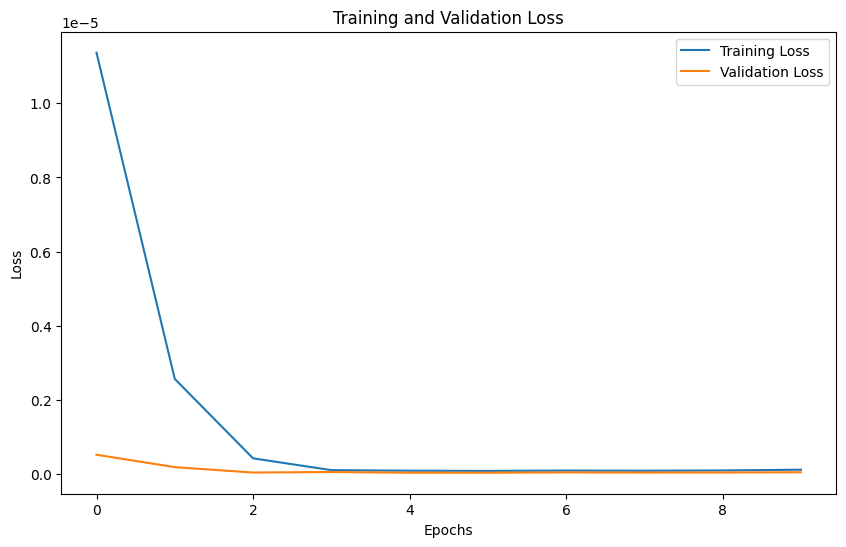

In [ ]:
# Plot the training loss and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [ ]:
percentage_change_dict = {}

for stock, forecasted_prices in forecast_dict.items():
    initial_price = forecasted_prices[0]
    final_price = forecasted_prices[-1]


    percentage_change = ((final_price - initial_price) / initial_price) * 100

    percentage_change_dict[stock] = percentage_change

forecast_df = pd.DataFrame(
    list(percentage_change_dict.items()),
    columns=['Stock_Name', 'Forecasted_Return (%)']
)


print(forecast_df)


          Stock_Name Forecasted_Return (%)
0   ADANIENTERPRISES          [-13.959882]
1         ADANIPORTS          [-1.4776044]
2         APOLLOHOSP           [19.397635]
3         ASIANPAINT           [13.544156]
4           AXISBANK           [-44.19466]
5         BAJAJ-AUTO          [-52.762222]
6         BAJAJFINSV          [-14.696908]
7         BAJFINANCE            [23.78377]
8         BHARTIARTL           [2.8801348]
9               BPCL         [-0.06313476]
10         BRITANNIA          [-13.851137]
11             CIPLA          [-20.649818]
12         COALINDIA           [-5.845886]
13          DIVISLAB          [-11.292733]
14           DRREDDY           [-38.73647]
15         EICHERMOT          [-31.092834]
16            GRASIM          [-22.557728]
17           HCLTECH          [-19.377892]
18          HDFCBANK            [4.905634]
19          HDFCLIFE           [-8.142215]
20        HEROMOTOCO           [-23.71189]
21          HINDALCO            [6.926448]
22         

In [ ]:
market_fea_df = pd.read_excel('market_features.xlsx')
market_fea_df = market_fea_df.sort_values(by='Stock_Name').reset_index()

In [ ]:
market_fea_df = market_fea_df.drop(columns=['index'])

In [ ]:
# Merge the forecasted returns DataFrame with the existing stock data
combined_df = pd.merge(market_fea_df, forecast_df, on='Stock_Name', how='left')

In [ ]:
combined_df

,Stock_Name,Market Cap(in Cr.),P/E,Ind P/E,EPS,P/B,Debt to Equity,GPM Last Quarter,OPM,Piotroski score,Dividend Yield,Forecasted_Return (%)
0,ADANIENTERPRISES,342057,97.40,35.90,28.40,8.75,1.67,0.456,0.1180,6,0.0004,[-13.959882]
1,ADANIPORTS,317108,35.80,35.80,37.60,6.01,0.94,1.000,0.5840,8,0.0041,[-1.4776044]
2,APOLLOHOSP,92009,103.00,48.40,62.50,13.30,0.77,0.485,0.1250,6,0.0025,[19.397635]
3,ASIANPAINT,281467,55.40,50.70,53.00,15.00,0.13,0.425,0.2030,6,0.0113,[13.544156]
4,AXISBANK,396484,15.00,12.20,85.50,2.52,8.25,1.000,0.6450,4,0.0008,[-44.19466]
5,BAJAJ-AUTO,262732,32.80,156.00,285.00,9.07,0.07,0.305,0.1980,7,0.0085,[-52.762222]
6,BAJAJFINSV,260527,32.00,24.20,51.10,4.31,4.79,1.000,0.3700,5,0.0006,[-14.696908]
7,BAJFINANCE,426028,29.50,24.20,233.00,5.58,3.84,1.000,0.7070,4,0.0052,[23.78377]
8,BHARTIARTL,876075,73.60,61.90,13.20,10.10,2.63,1.000,0.5220,5,0.0027,[2.8801348]
9,BPCL,133734,6.86,10.50,43.90,1.77,0.72,0.110,0.0752,8,0.0341,[-0.06313476]


In [ ]:
from scipy.optimize import minimize

# Assume we have forecasted returns and a covariance matrix
forecasted_returns = combined_df['Forecasted_Return (%)'].values / 100  # Convert to decimal
cov_matrix_opt = covariance_matrix_weekly  # Covariance matrix based on historical returns

# Extract stock features
market_cap = combined_df['Market Cap(in Cr.)'].values
pe_ratio = combined_df['P/E'].values
ind_pe_ratio = combined_df['Ind P/E'].values
piotroski_score = combined_df['Piotroski score'].values
dividend_yield = combined_df['Dividend Yield'].values / 100  # Convert to decimal

# User-defined inputs
user_risk_tolerance = int(input("Enter risk tolerance (scale 1-10) : "))  # Risk tolerance input (scale 1-10)
user_income = int(input("Enter your income : "))  # User's income input

# Risk-free rate assumption (can be adjusted)
risk_free_rate = 0.05

# Minimum expected return based on user income (for instance, aim for 10% of annual income)
target_return = (user_income * 0.10) / user_income  # Assuming a target of 10% return on investment

# Adjust risk tolerance: higher risk tolerance increases the allowable portfolio standard deviation
risk_multiplier = 1 + (user_risk_tolerance / 10)

# Feature weights (you can adjust these based on user preference)
feature_weights = {
    'market_cap_weight': 0.1,     # Preference for higher market cap
    'pe_ratio_weight': 0.1,       # Preference for lower P/E ratio
    'piotroski_score_weight': 0.2,  # Preference for higher Piotroski score
    'dividend_yield_weight': 0.2   # Preference for higher Dividend Yield
}

# Custom score for each stock based on these features (you can modify the function to better fit user preferences)
def custom_stock_score(weights):
    # Normalize the features
    normalized_market_cap = market_cap / np.max(market_cap)
    normalized_pe_ratio = 1 / pe_ratio
    normalized_piotroski_score = piotroski_score / np.max(piotroski_score)
    normalized_dividend_yield = dividend_yield / np.max(dividend_yield)

    # Calculate custom score
    score = (feature_weights['market_cap_weight'] * np.sum(weights * normalized_market_cap) +
             feature_weights['pe_ratio_weight'] * np.sum(weights * normalized_pe_ratio) +
             feature_weights['piotroski_score_weight'] * np.sum(weights * normalized_piotroski_score) +
             feature_weights['dividend_yield_weight'] * np.sum(weights * normalized_dividend_yield))

    return score

# Objective function: minimize the negative Sharpe ratio with a risk tolerance factor and include the custom score
def objective_function(weights, forecasted_returns, cov_matrix, risk_free_rate, risk_multiplier):
    portfolio_return = np.sum(weights * forecasted_returns)
    portfolio_stddev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * risk_multiplier
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_stddev
    custom_score = custom_stock_score(weights)

    # Combine Sharpe ratio and custom score into the objective
    return -(0.5 * sharpe_ratio + 0.5 * custom_score)

def pe_ratio_constraint(weights):
    weighted_pe_ratio = np.sum(weights * pe_ratio)
    weighted_ind_pe_ratio = np.sum(weights * ind_pe_ratio)
    return weighted_ind_pe_ratio - weighted_pe_ratio  # Ensures P/E ratio < Ind P/E

# # Additional constraint to select only 5 stocks (cardinality constraint)
# def cardinality_constraint(weights):
#     return 5 - np.sum(weights > 0.0001)  # Allow only 5 non-zero weights


# Constraints: sum of weights = 1, and expected return should exceed the target return
constraints = [
    {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1},  # Sum of weights = 1
    {'type': 'ineq', 'fun': lambda weights: np.sum(weights * forecasted_returns) - target_return},  # Ensure target return
    {'type': 'ineq', 'fun': lambda weights: np.sum(weights * piotroski_score) - 5},  # Minimum Piotroski score (adjustable)
    {'type': 'ineq', 'fun': pe_ratio_constraint}, # P/E ratio < Industry P/E ratio constraint
    # {'type': 'eq', 'fun': cardinality_constraint}
]

# Max weight constraints (optional)
max_weight = 0.15  # Maximum weight for a single stock
bounds = [(0, max_weight) for _ in range(len(forecasted_returns))]

# Initial guess (equal allocation)
initial_weights = np.array([1/len(forecasted_returns)] * len(forecasted_returns))

# Perform the optimization
optimal_solution = minimize(objective_function, initial_weights,
                            args=(forecasted_returns, cov_matrix_opt, risk_free_rate, risk_multiplier),
                            method='SLSQP', bounds=bounds, constraints=constraints)

# Get the optimal portfolio weights
optimal_weights_new = optimal_solution.x
print(f'Optimized Portfolio Weights based on risk tolerance, income, and stock features:\n {optimal_weights_new}')


Enter risk tolerance (scale 1-10) : 9
Enter your income : 400000
Optimized Portfolio Weights based on risk tolerance, income, and stock features:
 [1.59591302e-12 1.15035796e-12 4.20440283e-02 1.49922389e-01
 4.95402724e-14 5.76884968e-09 1.76958952e-12 7.76140560e-05
 2.77090808e-14 8.61558986e-13 4.21980760e-14 4.21918718e-14
 1.74156373e-13 2.77602988e-14 6.40251374e-14 2.64656067e-18
 1.53941932e-12 2.21325240e-02 2.76804924e-14 2.77210805e-14
 4.41896366e-11 1.32174718e-01 4.22087188e-14 1.74577557e-12
 1.16633882e-12 1.49988397e-01 8.40268688e-14 2.12676695e-12
 2.76846136e-14 1.07324597e-12 4.12119511e-05 1.20603403e-12
 1.09492716e-12 1.49999972e-01 1.49922386e-01 9.40163119e-11
 6.21332604e-14 2.77125260e-14 6.95081013e-14 3.77291080e-14
 1.60783945e-08 6.21816634e-14 3.77533848e-14 1.23496325e-18
 1.49922386e-01 5.21886299e-14 8.40765006e-14 1.96545717e-12
 2.57539598e-12 5.37743524e-02]


In [ ]:
# Convert optimized weights into percentages
optimal_weights_per = optimal_weights_new * 100

# Assuming forecast_dict contains stock symbols as keys
stock_names = list(forecast_dict.keys())

# Print the weights in percentage format with stock names
print("Optimized Portfolio Weights in Percentage:")
for stock, weight in zip(stock_names, optimal_weights_per):
    print(f'{stock}: {weight:.4f}%')

Optimized Portfolio Weights in Percentage:
ADANIENTERPRISES: 0.0000%
ADANIPORTS: 0.0000%
APOLLOHOSP: 4.2044%
ASIANPAINT: 14.9922%
AXISBANK: 0.0000%
BAJAJ-AUTO: 0.0000%
BAJAJFINSV: 0.0000%
BAJFINANCE: 0.0078%
BHARTIARTL: 0.0000%
BPCL: 0.0000%
BRITANNIA: 0.0000%
CIPLA: 0.0000%
COALINDIA: 0.0000%
DIVISLAB: 0.0000%
DRREDDY: 0.0000%
EICHERMOT: 0.0000%
GRASIM: 0.0000%
HCLTECH: 2.2133%
HDFCBANK: 0.0000%
HDFCLIFE: 0.0000%
HEROMOTOCO: 0.0000%
HINDALCO: 13.2175%
HUL: 0.0000%
ICICIBANK: 0.0000%
INDUSINDBK: 0.0000%
INFY: 14.9988%
ITC: 0.0000%
JSWSTEEL: 0.0000%
KOTAKBANK: 0.0000%
LT: 0.0000%
LTIM: 0.0041%
M&M: 0.0000%
MARUTI: 0.0000%
NESTLEIND: 15.0000%
NTPC: 14.9922%
ONGC: 0.0000%
POWERGRID: 0.0000%
RELIANCE: 0.0000%
SBI: 0.0000%
SBILIFE: 0.0000%
SHRIRAMFIN: 0.0000%
SUNPHARMA: 0.0000%
TATACONSUM: 0.0000%
TATAMOTORS: 0.0000%
TATASTEEL: 14.9922%
TCS: 0.0000%
TECHM: 0.0000%
TITAN: 0.0000%
ULTRACEMCO: 0.0000%
WIPRO: 5.3774%


In [ ]:
# Convert optimized weights into percentages
optimal_weights_per = optimal_weights_new * 100

# Assuming forecast_dict contains stock symbols as keys
stock_names = list(forecast_dict.keys())

# Create a list of tuples (stock, weight) and sort by weight in descending order
stock_weights = list(zip(stock_names, optimal_weights_per))
stock_weights_sorted = sorted(stock_weights, key=lambda x: x[1], reverse=True)

# Print only the top 5 allocated stocks
print("Top 5 Allocated Stocks in Percentage:")
for stock, weight in stock_weights_sorted[:5]:
    print(f'{stock}: {weight:.4f}%')


Top 5 Allocated Stocks in Percentage:
NESTLEIND: 15.0000%
INFY: 14.9988%
ASIANPAINT: 14.9922%
TATASTEEL: 14.9922%
NTPC: 14.9922%
